# Assignment-4

This notebook contains the coding questions to test the proficiency in `Object Oriented Programming` in python.

### Date: 13th September, 2026

### Steps to solve and upload the assignment 

- Download the notebook in your local machine.
- Solve the questions in the notebook and save it.
- Rename the file as `Assignment-04-<your_name>_<your_surname>.ipynb`. For example if your name is Dipika Chopra then name the file as `Assignment-04-Dipika_Chopra.ipynb`.
- Upload the solved notebook in your github repo under the folder **Assignment-4**.
- Upload the solved notebook in the google drive location: https://drive.google.com/drive/folders/1orNSmlOr2wMcrnu6zYeLwsY_JeUodCUq?usp=drive_link 
<h3><span style="color:red"> Deadline: 30th Sep, 2026 </span></h3>

## Problem-1

Design a system for a library. Include classes for `Book`, `Patron`, and `Library`.

- The `Book` class should have attributes for title, author, ISBN, and a method `is_available()` that returns `True` if the book is not currently checked out and `False` otherwise. It should also have a method `check_out()` that marks the book as checked out and a method `check_in()` that marks it as available.
- The `Patron` class should have attributes for name and patron ID and a method `borrow_book(book)` that associates a book with the patron.
- The `Library` class should have a collection of `Book` objects and `Patron` objects. It should have methods to `add_book(book)`, `add_patron(patron)`, `lend_book(book, patron)`, and `return_book(book)`. The `lend_book` method should only allow a book to be lent if it's available and the patron exists in the library.


Test your implementation.

In [2]:
import math
import this
from atexit import register


class Book:

    def __init__(self, title, author, ISBN):
        self.title = title
        self.author = author
        self.ISBN = ISBN
        self.__book_availability = True

    def is_available(self):
        return self.__book_availability

    def check_in(self):
        self.__book_availability = False

    def check_out(self):
        self.__book_availability = True

    def __repr__(self) -> str:
        return f"{self.title}"


In [3]:

class Patron:

    def __init__(self, name, id):
        self.name = name
        self.id = id
        self.books_borrowed = []

    def borrow_book(self, book):
        self.books_borrowed.append(book)

    def get_borrowed_books(self):
        return self.books_borrowed


In [4]:
class Library:

    def __init__(self):
        self.books = []
        self.patrons = []
        self.register = {}

    def add_book(self, book):
        self.books.append(book)

    def add_patron(self, patron):
        self.patrons.append(patron)

    def lend_book(self, book, patron):
        if book.is_available() and self.patrons.__contains__(patron):
            book.check_in()
            patron.borrow_book(book)
            self.register[book.ISBN] = patron
        else:
            print(f"{book.title} book is not available")

    def return_book(self, book):
        if book.is_available():
            print(f"{book.title} book is available, nothing to return")
            return

        book.check_out()
        patron = self.register.get(book.ISBN)
        patron.books_borrowed.remove(book)




In [5]:
class LibraryManager:

    library = Library()

    book1 = Book("book 1", "author 1", "ISBN121")
    book2 = Book("book 2", "author 2", "ISBN122")
    book3 = Book("book 3", "author 3", "ISBN123")
    library.add_book(book1)
    library.add_book(book2)
    library.add_book(book3)

    patron1 = Patron("name 1", "id 1")
    patron2 = Patron("name 2", "id 2")
    patron3 = Patron("name 3", "id 3")
    library.add_patron(patron1)
    library.add_patron(patron2)
    library.add_patron(patron3)

    print(f"{book1} is available {book1.is_available()}")

    library.return_book(book1)



book 1 is available True
book 1 book is available, nothing to return


## Problem-2

Create an base class `Shape` with an method `area()` and another method `perimeter()`. Then, create classes `Rectangle` and `Circle` that inherit from `Shape` and implement the `area()` method. The `perimeter()` method in `Shape` should raise a `NotImplementedError`. Implement the `perimeter()` method in `Rectangle` and `Circle`.

Test your implementation.

In [30]:
import math
class Shape:
    def __init__(self, name):
        self.name = name

    def area(self):
         raise NotImplementedError("Subclass must implement area")

    def perimeter(self):
       raise NotImplementedError("Subclass must implement perimeter")


In [35]:
class Rectangle(Shape):

    def __init__(self, name, length, width):
        super().__init__(name)
        self.length = length
        self.width = width

    def area(self):
        return self.length*self.width

    def perimeter(self):
        return 2 * (self.length + self.width)



In [44]:
class Circle(Shape):

    def __init__(self, name, radius):
        super().__init__(name)
        self.radius = radius

    def area(self):
        return math.pi * self.radius ** 2

    def perimeter(self):
        return 2 * math.pi * self.radius

In [46]:
class TestShape:

    circle = Circle("Circle", 4)
    rectangle = Rectangle("Rectangle", 5, 6)

    print(round(circle.area(), 2))
    print(round(circle.perimeter(), 2))

    print(rectangle.area())
    print(rectangle.perimeter())

50.27
25.13
30
22


l## Problem-3

Design a system to model different types of employees in a company. There should be a base `Employee` class with attributes for `name` and `employee_id`. Create two subclasses: `SalariedEmployee` with an attribute for `monthly_salary` and a method `calculate_paycheck()` that returns the monthly salary, and `HourlyEmployee` with attributes for `hourly_rate` and `hours_worked`, and a `calculate_paycheck()` method that returns the total pay for the week. Demonstrate creating instances of both employee types and calling their `calculate_paycheck()` methods.

Test your implementation.

In [50]:
class Employee:

    def __init__(self, name, employee_id):
        self.name = name
        self.employee_id = employee_id


In [51]:
class SalariedEmployee(Employee):

    def __init__(self, name, employee_id, monthly_salary):
        super().__init__(name, employee_id)
        self.monthly_salary = monthly_salary

    def calculate_paycheck(self):
        return self.monthly_salary


In [52]:
class HourlyEmployee(Employee):

    def __init__(self, name, employee_id, hourly_rate, hours_worked):
        super().__init__(name, employee_id)
        self.employee_id = employee_id
        self.hourly_rate = hourly_rate
        self.hours_worked = hours_worked

    def calculate_paycheck(self):
        return self.hourly_rate * self.hours_worked


In [57]:
class Company:

    employee1 = SalariedEmployee("John", "emp_1", 500_000)
    employee2 = HourlyEmployee("Pat", "emp_2", 600, 240)

    print(f"{employee1.name} gets ${employee1.calculate_paycheck():,.2f}")
    print(f"{employee2.name} gets ${employee2.calculate_paycheck():,.2f}")


John gets $500,000.00
Pat gets $144,000.00


## Problem-4

Design a class `polynomial` of one variable which will have attributes `degree`, a positive integer and `coefficients`, a list of floating point numbers. 
`degree` means the highest power of the variable and `coefficients` are the coefficient of individual terms.

A polynomial of degree `n` has `n+1` coefficients. 

- Example-1:
$$ 3x^4 + 5x^3 + x^2 + 9x + 10 $$
This is a polynomial of degree 4 and coefficients are [3, 5, 1, 9, 10].

- Example-2: (some coefficients could be zero)
$$ 0.7x^3 + 2.5x $$
Here the degree of polynomial is 3 and coefficients are [0.7, 0, 2.5, 0].

A polynomial of degree zero is just a constant value. 

In the `polynomial` class, you need to implement the following methods:
- `evaluate(x)` which will evaluate the polynomial for a given value of the variable x.
- `plot([x1, x2])` this will plot the polynomial for a given range of x1 to x2 of the variable.
- `derivative(x)` This will evaluate the derivative (differentiation) of the polynomial for a given value of the variable x.
- `plot_derivative([x1, x2])` this will plot the derivative of the polynomial for a given range of x1 to x2 of the variable.

The class should have basic checks, such that the number of coefficients provided by the user should be degree + 1 and the degree should be a positive integer. 

Test your implementation. 

In [93]:
import numpy as np
import matplotlib.pyplot as plt

class Product:
    def __init__(self, name, price):
        self.name = name
        self.price = price
class Product:
    def __init__(self, name, price):
        self.name = name
        self.price = price
class Polynomial:

    def __init__(self, degree, coefficients):
        self.degree = degree
        self.coefficients = coefficients

    def show_function(self):
        funct = ""
        temp_degree = self.degree
        for i in range(self.degree+1):
            if temp_degree == 0:
                funct = funct + self.coefficients[i]
            else:
                funct = funct + "+" f"{self.coefficients[i]}x^{temp_degree-1}"

        print(funct)

    def evaluate(self, x_value):
        result = 0
        for i in range(len(self.coefficients)):
            result += self.coefficients[i] * (x_value ** self.degree-i)

        return result

    def plot(self, x):
        x_value= np.linspace(x[0], x[1], 100)
        y_value= []
        for i in x_value:
            y_value.append(self.evaluate(i))

        plt.figure(figsize=(10,7))
        plt.plot(x_value, y_value)
        plt.grid()
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.show()





Evaluate: 374
+3x^3+5x^3+1x^3+9x^3+10x^3


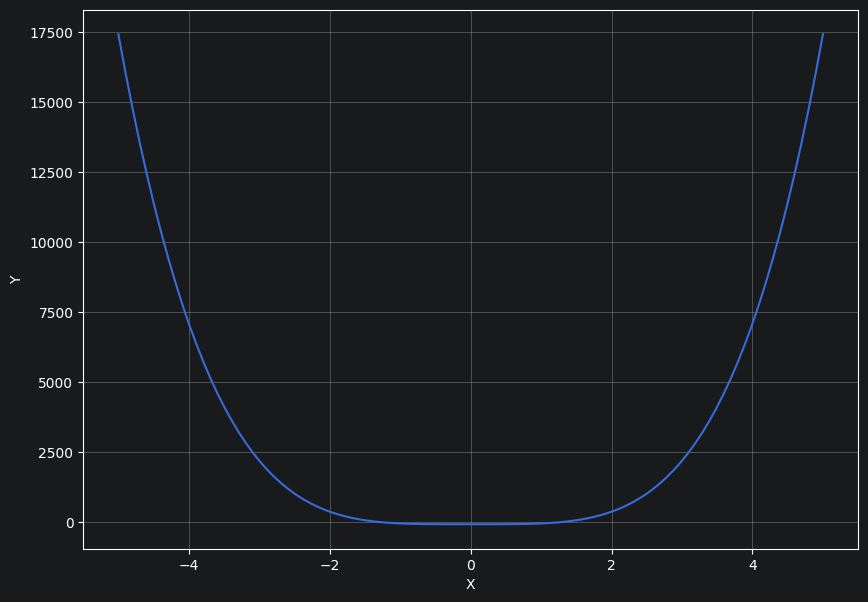

In [94]:
class TestPolynomial:

    poly = Polynomial(4, [3, 5, 1, 9, 10])

    print(f"Evaluate: {poly.evaluate(2)}")

    poly.show_function()


    poly.plot([-5,5])

## Problem-5

Design a system to model a simple online shopping cart. Create a class `Product` with attributes for `name` and `price`. Then, create a `ShoppingCart` class that has a list to store `Product` objects. Implement methods to `add_item(product)`, `remove_item(product_name)`, and `calculate_total()`.

In [59]:
class Product:
    def __init__(self, name, price):
        self.name = name
        self.price = price

In [73]:
class ShoppingCart:

    def __init__(self):
        self.cart_items = []

    def add_item(self, product: Product):
        self.cart_items.append(product)

    def remove_item(self, product_name):
        for product in self.cart_items:
            if product.name == product_name:
                self.cart_items.remove(product)
                return

    def calculate_total(self):
        cart_price = 0
        for items in self.cart_items:
            cart_price += items.price

        return cart_price

    def show_cart_items(self):
        for item in self.cart_items:
            print(f"{item.name} price $ {item.price:,.2f}")


In [77]:
hnlnclass OnlineShopping:

    product1 = Product("laptop", 400_00)
    product2 = Product("laptop mouse", 50)
    product3 = Product("mobile", 2300)


    shopping_cart = ShoppingCart()
    shopping_cart.add_item(product1)
    shopping_cart.add_item(product2)
    shopping_cart.add_item(product3)


    shopping_cart.show_cart_items()

    print(f"Total amount: $ {shopping_cart.calculate_total():,.2f}")

    shopping_cart.remove_item("mobile")

    print("After removing an item from cart")
    shopping_cart.show_cart_items()

    print(f"Total amount: $ {shopping_cart.calculate_total():,.2f}")



laptop price $ 40,000.00
laptop mouse price $ 50.00
mobile price $ 2,300.00
Total amount: $ 42,350.00
After removing an item from cart
laptop price $ 40,000.00
laptop mouse price $ 50.00
Total amount: $ 40,050.00
